# E-Commerce Sales & Customer Intelligence Analysis

## Project Overview

This notebook implements the Python analysis layer of the **E-Commerce Sales & Customer Intelligence Dashboard**.

It covers data quality checks, feature engineering, sales and return analysis, customer analysis, RFM segmentation, and cohort retention. Outputs are written to project-relative `data/processed/` and `data/cleaned/` folders so the workflow can be reproduced without machine-specific file paths.

The resulting datasets are used by the SQL analysis and Power BI dashboard.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)

# Project-relative paths
# Expected structure:
# E-Commerce Data Analytics/
# ├── data/raw/
# ├── data/cleaned/
# ├── data/processed/
# └── python/
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

RAW_DIR = DATA_DIR / "raw"
CLEANED_DIR = DATA_DIR / "cleaned"
PROCESSED_DIR = DATA_DIR / "processed"

CLEANED_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

RAW_FILE = RAW_DIR / "data.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw input: {RAW_FILE}")


## 1. Loading the Dataset

The raw Online Retail dataset is loaded into a Pandas DataFrame for inspection
and subsequent data preparation.

In [10]:
df = pd.read_csv(
    RAW_FILE,
    encoding="latin1"
)

df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## 2. Initial Dataset Inspection

The dataset is examined to understand its dimensions, columns, data types,
missing values, duplicate records, unique values, and basic numerical statistics.

In [12]:
df.shape

(541909, 8)

In [14]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [19]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [22]:
df.duplicated().sum()

5268

In [24]:
df.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

## 3. Transaction Quality Analysis

Before cleaning the dataset, potentially problematic transactions are investigated.
This includes negative quantities, zero-priced transactions, missing customer IDs,
and missing product descriptions.

Negative quantities are retained initially because they represent return activity
that will be analysed separately.

In [27]:
df[["Quantity","UnitPrice"]].describe()

,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


In [29]:
(df["Quantity"]<0).sum()

10624

In [31]:
df[df["Quantity"]<0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom


In [33]:
(df["UnitPrice"]==0).sum()

2515

In [35]:
df[df["UnitPrice"]==0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom


In [37]:
missing_customer_pct = (
    df["CustomerID"].isnull().mean() * 100
)

print(f"Missing CustomerID: {missing_customer_pct:.2f}%")

Missing CustomerID: 24.93%


In [39]:
df[df["Description"].isnull()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom


In [41]:
df["Description"].isnull().sum()

1454

In [43]:
quality_summary = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Total Columns",
        "Duplicate Rows",
        "Missing Descriptions",
        "Missing Customer IDs",
        "Negative Quantity Rows",
        "Zero Price Rows"
    ],
    "Value": [
        len(df),
        len(df.columns),
        df.duplicated().sum(),
        df["Description"].isnull().sum(),
        df["CustomerID"].isnull().sum(),
        (df["Quantity"] < 0).sum(),
        (df["UnitPrice"] == 0).sum()
    ]
})

quality_summary

,Metric,Value
0,Total Rows,541909
1,Total Columns,8
2,Duplicate Rows,5268
3,Missing Descriptions,1454
4,Missing Customer IDs,135080
5,Negative Quantity Rows,10624
6,Zero Price Rows,2515


In [44]:
cancellations = df[
    df["InvoiceNo"].astype(str).str.startswith("C")
]

print("Cancellation rows:", len(cancellations))


Cancellation rows: 9288


In [47]:
cancellations.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom


In [49]:
cancellations["Quantity"].sum()

-277574

In [51]:
negative_qty = df[df["Quantity"] < 0]

negative_qty["InvoiceNo"].astype(str).str.startswith("C").value_counts()

InvoiceNo
True     9288
False    1336
Name: count, dtype: int64

In [53]:
zero_price = df[df["UnitPrice"] == 0]

zero_price[[
    "InvoiceNo",
    "StockCode",
    "Description",
    "Quantity",
    "CustomerID",
    "Country"
]].head(20)

,InvoiceNo,StockCode,Description,Quantity,CustomerID,Country
622,536414,22139,NaN,56,NaN,United Kingdom
1970,536545,21134,NaN,1,NaN,United Kingdom
1971,536546,22145,NaN,1,NaN,United Kingdom
1972,536547,37509,NaN,1,NaN,United Kingdom
1987,536549,85226A,NaN,1,NaN,United Kingdom
1988,536550,85044,NaN,1,NaN,United Kingdom
2024,536552,20950,NaN,1,NaN,United Kingdom
2025,536553,37461,NaN,3,NaN,United Kingdom
2026,536554,84670,NaN,23,NaN,United Kingdom
2406,536589,21777,NaN,-10,NaN,United Kingdom


In [55]:
zero_price["Description"].value_counts().head(20)

Description
check                              159
?                                   47
damages                             45
damaged                             43
found                               25
sold as set on dotcom               20
adjustment                          16
Damaged                             14
Unsaleable, destroyed.               9
thrown away                          9
FRENCH BLUE METAL DOOR SIGN 1        9
amazon                               8
FRENCH BLUE METAL DOOR SIGN 8        8
Found                                8
FRENCH BLUE METAL DOOR SIGN 4        7
RECIPE BOX PANTRY YELLOW DESIGN      7
Amazon                               7
FRENCH BLUE METAL DOOR SIGN No       7
??                                   7
OWL DOORSTOP                         7
Name: count, dtype: int64

## 4. Feature Engineering

Additional fields are created to make the dataset suitable for business analysis.

The main derived fields include:

* **Sales** = Quantity × Unit Price
* **Year** = Year extracted from InvoiceDate
* **Month** = Month extracted from InvoiceDate
* **MonthName** = Name of the transaction month
* **YearMonth** = Combined year-month period

These fields will be used for revenue analysis, time-series analysis, transaction classification, and dashboard development.


In [58]:
df["Sales"] = df["Quantity"] * df["UnitPrice"]

In [60]:
df[["Quantity", "UnitPrice", "Sales"]].head(10)

,Quantity,UnitPrice,Sales
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34
5,2,7.65,15.30
6,6,4.25,25.50
7,6,1.85,11.10
8,6,1.85,11.10
9,32,1.69,54.08


In [62]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
 8   Sales        541909 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 37.2+ MB


In [66]:
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["MonthName"] = df["InvoiceDate"].dt.month_name()
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M").astype(str)

In [72]:
df[["InvoiceDate", "Year", "Month", "MonthName", "YearMonth"]].head()

,InvoiceDate,Year,Month,MonthName,YearMonth
0,2010-12-01 08:26:00,2010,12,December,2010-12
1,2010-12-01 08:26:00,2010,12,December,2010-12
2,2010-12-01 08:26:00,2010,12,December,2010-12
3,2010-12-01 08:26:00,2010,12,December,2010-12
4,2010-12-01 08:26:00,2010,12,December,2010-12


## 5. Data Cleaning and Preparation

The dataset is cleaned and prepared for downstream analysis.

A copy of the current dataset is preserved before further transformations. Duplicate records are identified and removed where appropriate.

Transaction types are also classified so that sales and returns can be analyzed separately.

The objective is to create a consistent analysis-ready dataset while retaining important transaction information.

In [75]:
df_raw = df.copy()

In [77]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 5268


In [79]:
df = df.drop_duplicates().copy()

print("Rows after removing duplicates:", len(df))

Rows after removing duplicates: 536641


In [81]:
df["TransactionType"] = np.where(
    df["Quantity"] < 0,
    "Return",
    "Sale"
)

In [83]:
df["TransactionType"].value_counts()

TransactionType
Sale      526054
Return     10587
Name: count, dtype: int64

In [85]:
df[[
    "InvoiceNo",
    "Quantity",
    "UnitPrice",
    "Sales",
    "TransactionType"
]].head(10)

,InvoiceNo,Quantity,UnitPrice,Sales,TransactionType
0,536365,6,2.55,15.30,Sale
1,536365,6,3.39,20.34,Sale
2,536365,8,2.75,22.00,Sale
3,536365,6,3.39,20.34,Sale
4,536365,6,3.39,20.34,Sale
5,536365,2,7.65,15.30,Sale
6,536365,6,4.25,25.50,Sale
7,536366,6,1.85,11.10,Sale
8,536366,6,1.85,11.10,Sale
9,536367,32,1.69,54.08,Sale


In [87]:
# Authoritative sales population used throughout the project:
# TransactionType == "Sale" means Quantity > 0.
# Zero-price sales remain in the dataset and are not silently discarded.
df_sales = df[df["TransactionType"] == "Sale"].copy()


In [89]:
df_sales.shape

(534129, 14)

In [91]:
df_customer = df_sales[df_sales["CustomerID"].notna()].copy()

In [93]:
df_customer["CustomerID"] = (df_customer["CustomerID"].astype(int).astype(str))

In [95]:
df_customer["CustomerID"].head()

0    17850
1    17850
2    17850
3    17850
4    17850
Name: CustomerID, dtype: object

## 6. Exporting Analysis Datasets

The cleaned datasets are exported as CSV files so that the results can be reused in other parts of the project.

These exported datasets support the subsequent **SQL analysis, RFM analysis, cohort analysis, and Power BI dashboard**.

This also separates the data-preparation stage from the reporting and visualization stages.

In [99]:
df.to_csv(CLEANED_DIR / "online_retail_cleaned.csv", index=False)
df_sales.to_csv(CLEANED_DIR / "online_retail_sales.csv", index=False)
df_customer.to_csv(CLEANED_DIR / "online_retail_customer.csv", index=False)

print("Cleaned datasets exported successfully.")


In [119]:
print("Original rows:", len(df_raw))
print("Cleaned rows:", len(df))
print("Sales rows:", len(df_sales))
print("Customer rows:", len(df_customer))

Original rows: 541909
Cleaned rows: 536641
Sales rows: 534129
Customer rows: 401564


## 7. Core Business KPIs

The next step is to calculate the key business performance indicators for the retail business.

The primary KPIs include:

* Total Revenue
* Total Orders
* Total Customers
* Total Products
* Average Order Value (AOV)

These metrics provide a high-level view of overall business performance and are also used later to validate the Power BI dashboard.

In [122]:
total_revenue = df_sales["Sales"].sum()

print(f"Total Revenue: £{total_revenue:,.2f}")

Total Revenue: £9,748,131.07


In [124]:
total_orders = df_sales["InvoiceNo"].nunique()

print(f"Total Orders: {total_orders:,}")

Total Orders: 23,796


In [126]:
total_customers = df_customer["CustomerID"].nunique()

print(f"Total Customers: {total_customers:,}")

Total Customers: 4,371


In [128]:
total_products = df_sales["StockCode"].nunique()

print(f"Total Products: {total_products:,}")

Total Products: 3,938


In [130]:
average_order_value = total_revenue / total_orders

print(f"Average Order Value: £{average_order_value:,.2f}")

Average Order Value: £409.65


In [132]:
kpis = {
    "Total Revenue": total_revenue,
    "Total Orders": total_orders,
    "Total Customers": total_customers,
    "Total Products": total_products,
    "Average Order Value": round(average_order_value,2)
}
kpis

{'Total Revenue': 9748131.074,
 'Total Orders': 23796,
 'Total Customers': 4371,
 'Total Products': 3938,
 'Average Order Value': 409.65}

## 8. Sales and Product Analysis

This section examines sales performance over time and across products.

The analysis focuses on identifying revenue trends, high-performing products, and differences in sales performance across countries.

These results help identify the major drivers of overall revenue.

In [135]:
df_sales["InvoiceDate"] = pd.to_datetime(df_sales["InvoiceDate"])

### 8.1 Monthly Revenue Trend

Monthly revenue is aggregated to understand how sales change over time.

The resulting trend helps identify periods of higher and lower revenue and provides a time-based view of business performance.

In [138]:
monthly_revenue = (
    df_sales
    .groupby(df_sales["InvoiceDate"].dt.to_period("M"))["Sales"]
    .sum()
    .reset_index()
)

monthly_revenue.columns = ["Month", "Revenue"]

monthly_revenue["Month"] = monthly_revenue["Month"].astype(str)

monthly_revenue

,Month,Revenue
0,2010-12,746723.610
1,2011-01,558448.560
2,2011-02,497026.410
3,2011-03,682013.980
4,2011-04,492367.841
5,2011-05,722094.100
6,2011-06,689977.230
7,2011-07,680156.991
8,2011-08,703510.580
9,2011-09,1017596.682


In [ ]:
monthly_revenue.to_csv(PROCESSED_DIR / "monthly_revenue.csv", index=False)
print("Monthly revenue exported.")


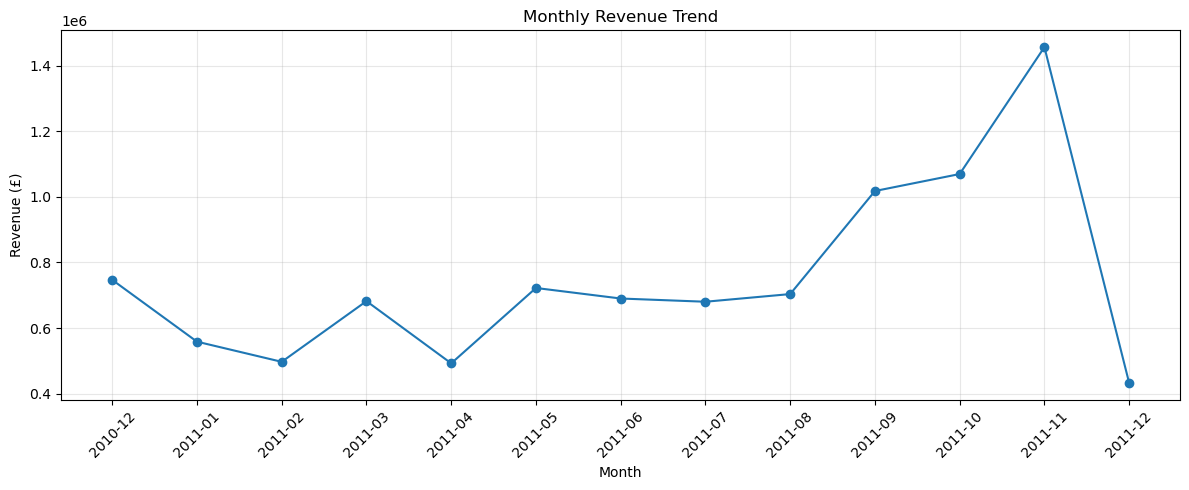

In [140]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue["Month"],
    monthly_revenue["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 8.2 Top Products by Revenue

Products are ranked based on the revenue generated from their sales.

The analysis helps identify the products that contribute most significantly to overall revenue and provides a basis for product-level performance analysis.


In [145]:
top_products = (
    df_sales
    .groupby("Description")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_products

,Description,Sales
0,DOTCOM POSTAGE,206245.48
1,REGENCY CAKESTAND 3 TIER,164459.49
2,WHITE HANGING HEART T-LIGHT HOLDER,99612.42
3,PARTY BUNTING,98243.88
4,JUMBO BAG RED RETROSPOT,92175.79
5,RABBIT NIGHT LIGHT,66661.63
6,POSTAGE,66230.64
7,PAPER CHAIN KIT 50'S CHRISTMAS,63715.24
8,ASSORTED COLOUR BIRD ORNAMENT,58792.42
9,CHILLI LIGHTS,53746.66


In [ ]:
top_products.to_csv(PROCESSED_DIR / "top_products.csv", index=False)
print("Top products exported.")


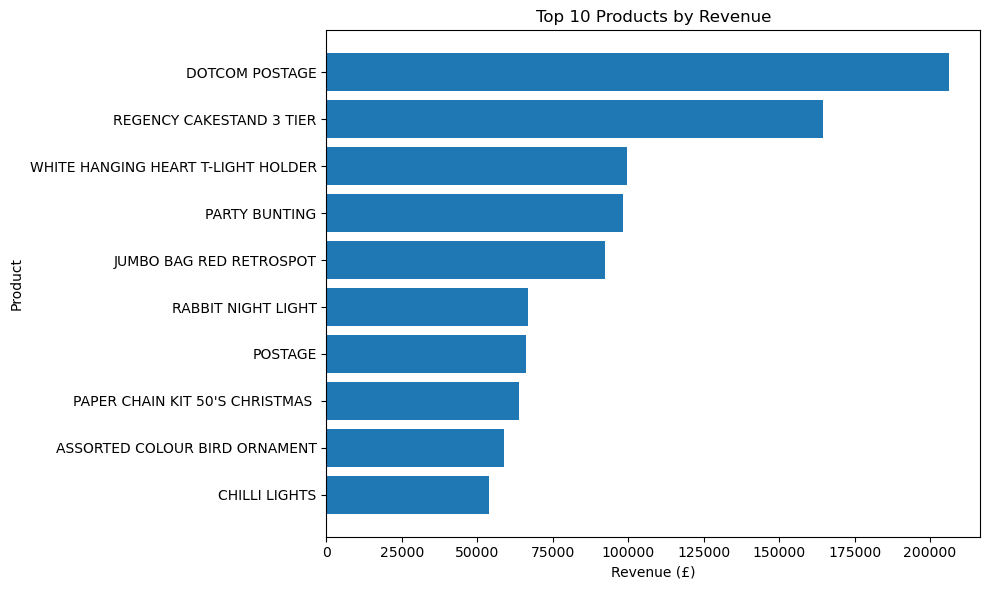

In [147]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_products["Description"][::-1],
    top_products["Sales"][::-1]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

### 8.3 Investigating Non-Standard Stock Codes

Some StockCodes represent non-product transactions such as postage, discounts, or other operational entries.

These records are investigated separately to avoid incorrectly treating them as normal physical products when analyzing product performance.


In [150]:
df_sales[
    df_sales["Description"].str.contains(
        "POSTAGE|DOTCOM|DISCOUNT",
        case=False,
        na=False
    )
][[
    "StockCode",
    "Description",
    "Quantity",
    "UnitPrice",
    "Sales"
]].groupby(
    ["StockCode", "Description"]
).agg(
    Quantity=("Quantity", "sum"),
    Revenue=("Sales", "sum")
).sort_values(
    "Revenue",
    ascending=False
)

,,Quantity,Revenue
StockCode,Description,,
DOT,DOTCOM POSTAGE,705,206245.48
POST,POSTAGE,3003,66230.64
gift_0001_30,Dotcomgiftshop Gift Voucher £30.00,7,175.53
gift_0001_50,Dotcomgiftshop Gift Voucher £50.00,4,167.56
gift_0001_20,Dotcomgiftshop Gift Voucher £20.00,10,167.05
gift_0001_40,Dotcomgiftshop Gift Voucher £40.00,3,100.70
22016,Dotcomgiftshop Gift Voucher £100.00,1,83.33
gift_0001_10,Dotcomgiftshop Gift Voucher £10.00,9,74.97
22351,DOTCOMGIFTSHOP TEA TOWEL,13,23.09


In [151]:
top_products_code = (
    df_sales
    .groupby(["StockCode", "Description"])
    .agg(
        Quantity=("Quantity", "sum"),
        Revenue=("Sales", "sum")
    )
    .sort_values("Revenue", ascending=False)
    .head(15)
    .reset_index()
)

top_products_code

,StockCode,Description,Quantity,Revenue
0,DOT,DOTCOM POSTAGE,705,206245.48
1,22423,REGENCY CAKESTAND 3 TIER,12996,164459.49
2,47566,PARTY BUNTING,18006,98243.88
3,85123A,WHITE HANGING HEART T-LIGHT HOLDER,35002,97659.94
4,85099B,JUMBO BAG RED RETROSPOT,47256,92175.79
5,23084,RABBIT NIGHT LIGHT,30631,66661.63
6,POST,POSTAGE,3003,66230.64
7,22086,PAPER CHAIN KIT 50'S CHRISTMAS,18876,63715.24
8,84879,ASSORTED COLOUR BIRD ORNAMENT,36282,58792.42
9,79321,CHILLI LIGHTS,10222,53746.66


In [153]:
product_sales = df_sales[~df_sales["Description"].str.contains("POSTAGE",case=False,na=False)].copy()

In [156]:
top_physical_products = (
    product_sales
    .groupby(["StockCode", "Description"])
    .agg(
        Quantity=("Quantity", "sum"),
        Revenue=("Sales", "sum")
    )
    .sort_values("Revenue", ascending=False)
    .head(10)
    .reset_index()
)

top_physical_products

,StockCode,Description,Quantity,Revenue
0,22423,REGENCY CAKESTAND 3 TIER,12996,164459.49
1,47566,PARTY BUNTING,18006,98243.88
2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,35002,97659.94
3,85099B,JUMBO BAG RED RETROSPOT,47256,92175.79
4,23084,RABBIT NIGHT LIGHT,30631,66661.63
5,22086,PAPER CHAIN KIT 50'S CHRISTMAS,18876,63715.24
6,84879,ASSORTED COLOUR BIRD ORNAMENT,36282,58792.42
7,79321,CHILLI LIGHTS,10222,53746.66
8,23298,SPOTTY BUNTING,8210,42030.67
9,22386,JUMBO BAG PINK POLKADOT,20992,41584.43


## 9. Geographic Sales Analysis

Revenue is aggregated by country to understand the geographic distribution of sales.

This analysis identifies the markets contributing the most revenue and provides a comparison of the business across different countries.

In [159]:
country_analysis = (
    df_sales
    .groupby("Country")
    .agg(
        Revenue=("Sales", "sum"),
        Orders=("InvoiceNo", "nunique"),
        Quantity=("Quantity", "sum")
    )
    .reset_index()
)

country_analysis["Average_Order_Value"] = (
    country_analysis["Revenue"] /
    country_analysis["Orders"]
)

country_analysis = country_analysis.sort_values(
    "Revenue",
    ascending=False
)

country_analysis.head(10)

,Country,Revenue,Orders,Quantity,Average_Order_Value
36,United Kingdom,8189252.304,21391,4385862,382.836347
24,Netherlands,284661.540,100,199552,2846.615400
10,EIRE,262993.380,360,142221,730.537167
14,Germany,221509.470,603,117339,367.345721
13,France,197317.110,461,110437,428.019761
0,Australia,137009.770,69,83335,1985.648841
33,Switzerland,56363.050,74,30312,761.662838
31,Spain,54756.030,105,26806,521.486000
3,Belgium,40910.960,119,23152,343.789580
32,Sweden,36585.410,46,35632,795.335000


In [ ]:
country_analysis.to_csv(PROCESSED_DIR / "country_analysis.csv", index=False)
print("Country analysis exported.")


## 10. Customer Analysis

Customer-level revenue is calculated to understand how sales are distributed across the customer base.

This analysis helps identify high-value customers and examine the concentration of revenue among different customer groups.

Customer-level analysis forms the foundation for the RFM segmentation performed in the next section.


In [162]:
customer_revenue = (
    df_customer
    .groupby("CustomerID")
    .agg(
        Revenue=("Sales", "sum"),
        Orders=("InvoiceNo", "nunique"),
        Quantity=("Quantity", "sum")
    )
    .reset_index()
)

customer_revenue["Average_Order_Value"] = (
    customer_revenue["Revenue"] /
    customer_revenue["Orders"]
)

customer_revenue = customer_revenue.sort_values(
    "Revenue",
    ascending=False
)

customer_revenue.head(10)

,CustomerID,Revenue,Orders,Quantity,Average_Order_Value
1702,14646,279489.02,76,196143,3677.487105
4232,18102,256438.49,62,64122,4136.104677
3757,17450,187322.17,55,69009,3405.857636
1894,14911,132458.73,248,76905,534.107782
55,12415,123725.45,26,76946,4758.671154
1344,14156,113214.59,66,56908,1715.372576
3800,17511,88125.38,46,63012,1915.769130
3201,16684,65892.08,31,49390,2125.550968
1004,13694,62690.54,60,61899,1044.842333
2191,15311,59284.19,118,37673,502.408390


## 11. RFM Customer Segmentation

RFM analysis is used to evaluate customer behavior based on three dimensions:

* **Recency (R):** How recently a customer made a purchase
* **Frequency (F):** How frequently a customer made purchases
* **Monetary (M):** How much revenue a customer generated

RFM analysis converts transaction-level data into customer-level behavioral metrics that can be used to identify different customer segments.


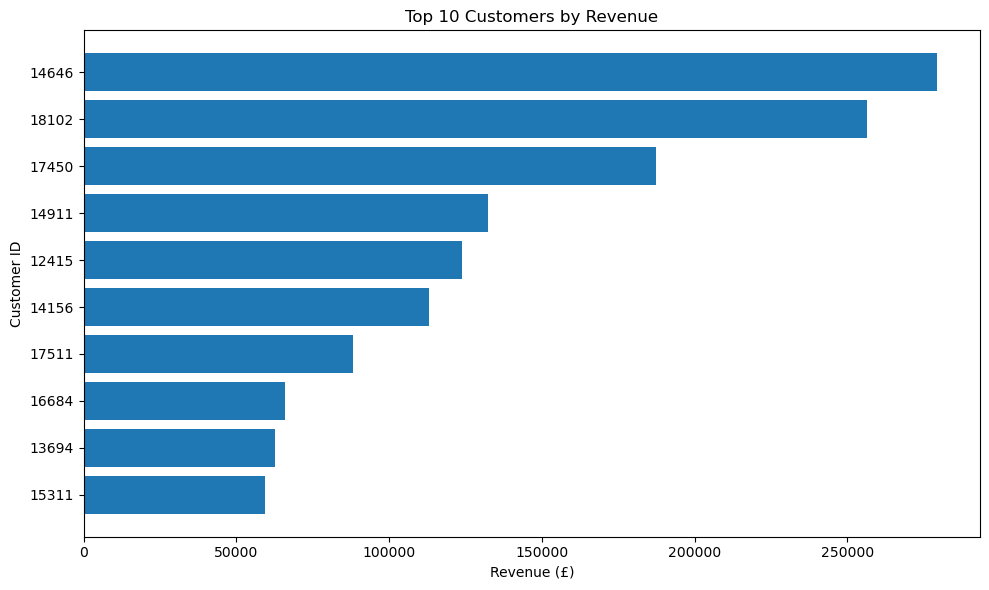

In [165]:
top_customers = customer_revenue.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_customers["CustomerID"].astype(str)[::-1],
    top_customers["Revenue"][::-1]
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Customer ID")

plt.tight_layout()
plt.show()

In [167]:
customer_revenue["Revenue"].describe()

count      4371.000000
mean       1893.964636
std        8219.586584
min       -4287.630000
25%         291.940000
50%         644.240000
75%        1608.940000
max      279489.020000
Name: Revenue, dtype: float64

In [169]:
customer_revenue["Revenue"].quantile(
    [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

0.25      291.940
0.50      644.240
0.75     1608.940
0.90     3497.140
0.95     5601.455
0.99    17231.393
Name: Revenue, dtype: float64

In [171]:
customer_revenue_sorted = customer_revenue.sort_values(
    "Revenue",
    ascending=False
).reset_index(drop=True)

top_10_pct_count = int(
    len(customer_revenue_sorted) * 0.10
)

top_10_revenue = customer_revenue_sorted.head(
    top_10_pct_count
)["Revenue"].sum()

total_customer_revenue = customer_revenue_sorted["Revenue"].sum()

top_10_contribution = (
    top_10_revenue /
    total_customer_revenue
) * 100

print(
    f"Top 10% of customers contribute "
    f"{top_10_contribution:.2f}% of customer revenue."
)

Top 10% of customers contribute 60.10% of customer revenue.


In [ ]:
customer_revenue.to_csv(PROCESSED_DIR / "customer_analysis.csv", index=False)
print("Customer analysis exported.")


### 11.1 RFM Calculation

RFM (Recency, Frequency, Monetary) analysis is used to segment customers based on their purchasing behaviour.

- **Recency:** How recently a customer made a purchase.
- **Frequency:** How frequently a customer placed orders.
- **Monetary:** How much revenue a customer generated.

Only positive-quantity transactions are used for RFM analysis so that customer value is based on actual purchases rather than returns.


In [174]:
# Use only positive-quantity transactions for customer RFM analysis
customer_rfm_data = df_customer[
    df_customer["Quantity"] > 0
].copy()

customer_rfm_data["InvoiceDate"] = pd.to_datetime(
    customer_rfm_data["InvoiceDate"]
)

# Reference date is one day after the latest customer purchase
reference_date = (
    customer_rfm_data["InvoiceDate"].max()
    + pd.Timedelta(days=1)
)

print("Reference Date:", reference_date)

Reference Date: 2011-12-10 12:50:00


In [176]:
# Calculate customer-level RFM metrics

rfm = (
    customer_rfm_data
    .groupby("CustomerID")
    .agg(
        Recency=(
            "InvoiceDate",
            lambda x: (reference_date - x.max()).days
        ),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("Sales", "sum")
    )
    .reset_index()
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [178]:
# Summary of RFM metrics

rfm[["Recency", "Frequency", "Monetary"]].describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


### 11.2 Assigning RFM Scores

Customers are divided into five groups (quintiles) for each RFM metric.

For Recency, a lower number of days is better, so the most recent customers receive the highest score.

For Frequency and Monetary, higher values receive higher scores.

In [181]:
# Assign RFM scores using five quantile groups

rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,12346,326,1,77183.60,1,1,5
1,12347,2,7,4310.00,5,5,5
2,12348,75,4,1797.24,2,4,4
3,12349,19,1,1757.55,4,1,4
4,12350,310,1,334.40,1,1,2


In [185]:
# Combine individual scores into a single RFM score

rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,326,1,77183.60,1,1,5,115
1,12347,2,7,4310.00,5,5,5,555
2,12348,75,4,1797.24,2,4,4,244
3,12349,19,1,1757.55,4,1,4,414
4,12350,310,1,334.40,1,1,2,112


### 11.3 Creating Customer Segments

Customers are classified into five business-oriented segments using their RFM scores:

- **High Value:** Strong recency, frequency, and monetary value.
- **Loyal:** Recent and frequent customers.
- **Recent:** Customers who purchased recently.
- **At Risk:** Customers who have not purchased recently but have relatively strong purchase frequency.
- **Low Engagement:** Remaining customers with comparatively weaker engagement.

In [188]:
# Assign business-oriented customer segments

def segment_customer(row):
    R = row["R_Score"]
    F = row["F_Score"]
    M = row["M_Score"]

    if R >= 4 and F >= 4 and M >= 4:
        return "High Value"

    elif R >= 4 and F >= 3:
        return "Loyal"

    elif R >= 4:
        return "Recent"

    elif R <= 2 and F >= 3:
        return "At Risk"

    else:
        return "Low Engagement"


rfm["Segment"] = rfm.apply(
    segment_customer,
    axis=1
)

rfm["Segment"].value_counts()

Segment
Low Engagement    1923
High Value         957
At Risk            643
Loyal              496
Recent             319
Name: count, dtype: int64

### 11.4 RFM Segment Analysis

The segment summary compares the number of customers, revenue contribution, and average RFM behaviour across customer segments.

In [193]:
segment_analysis = (
    rfm
    .groupby("Segment")
    .agg(
        Customers=("CustomerID", "count"),
        Revenue=("Monetary", "sum"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean")
    )
    .reset_index()
)

segment_analysis["Revenue_Percentage"] = (
    segment_analysis["Revenue"]
    / segment_analysis["Revenue"].sum()
    * 100
).round(2)

segment_analysis = segment_analysis.sort_values(
    "Revenue",
    ascending=False
)

segment_analysis

,Segment,Customers,Revenue,Avg_Recency,Avg_Frequency,Avg_Monetary,Revenue_Percentage
1,High Value,957,5791640.740,12.824451,11.123302,6051.871202,65.17
2,Low Engagement,1923,1617769.032,144.018721,1.995840,841.273548,18.20
0,At Risk,643,798052.511,152.844479,3.404355,1241.139208,8.98
3,Loyal,496,534526.871,16.161290,2.951613,1077.675143,6.01
4,Recent,319,145219.740,18.517241,1.241379,455.234295,1.63


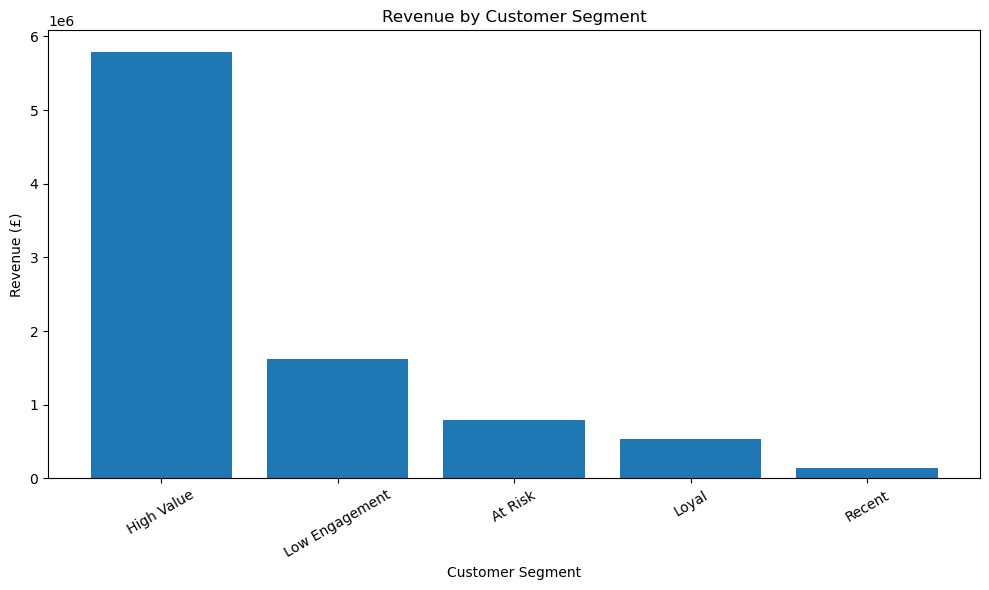

In [195]:
# Revenue contribution by customer segment

plt.figure(figsize=(10, 6))

plt.bar(
    segment_analysis["Segment"],
    segment_analysis["Revenue"]
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

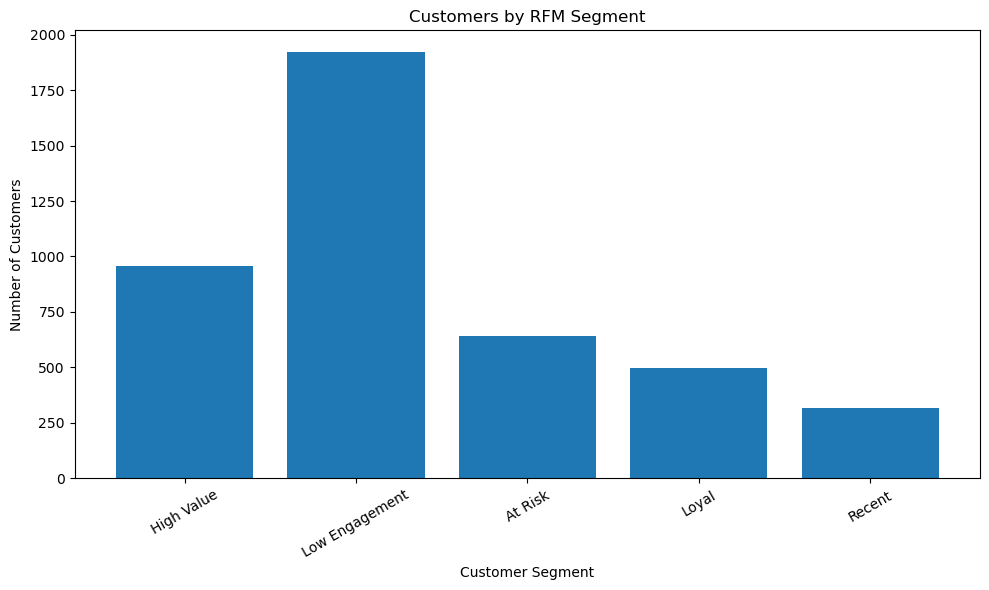

In [197]:
# Customer distribution by RFM segment

plt.figure(figsize=(10, 6))

plt.bar(
    segment_analysis["Segment"],
    segment_analysis["Customers"]
)

plt.title("Customers by RFM Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### 11.5 Validating RFM Results

The final RFM customer count is compared with the number of customers available for customer-level analysis. This confirms that the RFM calculation does not unexpectedly exclude customers.

In [200]:
print(
    "Customers available for RFM:",
    customer_rfm_data["CustomerID"].nunique()
)

print(
    "Customers in RFM output:",
    rfm["CustomerID"].nunique()
)

print(
    "Customers excluded from RFM:",
    customer_rfm_data["CustomerID"].nunique()
    - rfm["CustomerID"].nunique()
)

Customers available for RFM: 4338
Customers in RFM output: 4338
Customers excluded from RFM: 0


In [202]:
# Export customer-level RFM data
rfm.to_csv(
    PROCESSED_DIR / "customer_rfm.csv",
    index=False
)

# Export RFM segment summary
segment_analysis.to_csv(
    PROCESSED_DIR / "rfm_segment_summary.csv",
    index=False
)

print("RFM datasets exported successfully.")


RFM datasets exported successfully.


## 12. Return Analysis

Returns are analyzed separately from sales so that revenue, order volume, and customer behaviour are not distorted by negative transactions.

The analysis includes return revenue, return order counts, product-level return quantities, and identification of unusually large return transactions.


In [ ]:
df_returns = df[df["TransactionType"] == "Return"].copy()

return_revenue = -df_returns["Sales"].sum()
return_orders = df_returns["InvoiceNo"].nunique()

print(f"Return Revenue: £{return_revenue:,.2f}")
print(f"Return Orders: {return_orders:,}")


### 12.1 Product-Level Return Analysis

In [ ]:
return_by_product = (
    df_returns.groupby(["StockCode", "Description"])
    .agg(
        Return_Quantity=("Quantity", lambda x: abs(x.sum())),
        Return_Revenue=("Sales", lambda x: abs(x.sum()))
    )
    .sort_values("Return_Revenue", ascending=False)
    .reset_index()
)

return_by_product.head(10)


### 12.2 Return Anomaly Detection

A simple statistical rule is used to flag unusually large return transactions. This is an analytical flag rather than a claim that the transaction is erroneous.


In [ ]:
return_abs_qty = df_returns["Quantity"].abs()
return_threshold = return_abs_qty.quantile(0.99)

df_returns["IsAnomaly"] = return_abs_qty >= return_threshold

print(f"99th-percentile return quantity threshold: {return_threshold:,.0f}")
print(f"Flagged return-anomaly rows: {df_returns['IsAnomaly'].sum():,}")


## 13. Final Transaction Classification

The final transaction-level dataset preserves the original transaction information together with engineered fields and the return-anomaly flag.


In [ ]:
df["IsAnomaly"] = False
df.loc[df_returns.index, "IsAnomaly"] = df_returns["IsAnomaly"]

# Keep the project-level transaction classification consistent.
df["TransactionType"] = np.where(
    df["Quantity"] < 0,
    "Return",
    "Sale"
)

final_columns = [
    "InvoiceNo", "StockCode", "Description", "Quantity", "InvoiceDate",
    "UnitPrice", "CustomerID", "Country", "Sales", "Year", "Month",
    "MonthName", "YearMonth", "TransactionType", "IsAnomaly"
]
df = df[final_columns].copy()

FINAL_DATASET = PROCESSED_DIR / "online_retail_final.csv"
df.to_csv(FINAL_DATASET, index=False)

print(f"Final dataset exported to: {FINAL_DATASET}")
print(f"Rows: {len(df):,} | Columns: {len(df.columns)}")


## 14. Cohort Retention Analysis

Cohort analysis tracks customer retention by grouping customers according to the month of their first purchase and measuring subsequent purchasing activity.


In [ ]:
cohort_sales = df_sales[df_sales["CustomerID"].notna()].copy()
cohort_sales["CustomerID"] = cohort_sales["CustomerID"].astype(int)

cohort_sales["InvoiceMonth"] = cohort_sales["InvoiceDate"].dt.to_period("M")
cohort_sales["CohortMonth"] = (
    cohort_sales.groupby("CustomerID")["InvoiceDate"]
    .transform("min")
    .dt.to_period("M")
)

cohort_sales["CohortIndex"] = (
    (cohort_sales["InvoiceMonth"].dt.year - cohort_sales["CohortMonth"].dt.year) * 12
    + (cohort_sales["InvoiceMonth"].dt.month - cohort_sales["CohortMonth"].dt.month)
)

cohort_counts = (
    cohort_sales.groupby(["CohortMonth", "CohortIndex"])["CustomerID"]
    .nunique()
    .reset_index(name="Customers")
)

cohort_pivot = cohort_counts.pivot(
    index="CohortMonth",
    columns="CohortIndex",
    values="Customers"
)

cohort_retention = cohort_pivot.divide(cohort_pivot[0], axis=0) * 100
cohort_retention = cohort_retention.reset_index()

cohort_retention.columns = [
    "CohortMonth" if col == "CohortMonth" else f"Month_{int(col)}"
    for col in cohort_retention.columns
]

cohort_retention_path = PROCESSED_DIR / "cohort_retention.csv"
cohort_retention.to_csv(cohort_retention_path, index=False)

print(f"Cohort retention exported to: {cohort_retention_path}")
cohort_retention.head()


## 15. Final Project Outputs

The notebook produces the main datasets consumed by the SQL analysis and Power BI dashboard:

- `online_retail_final.csv`
- `monthly_revenue.csv`
- `top_products.csv`
- `country_analysis.csv`
- `customer_analysis.csv`
- `customer_rfm.csv`
- `rfm_segment_summary.csv`
- `cohort_retention.csv`

These files form the handoff from Python-based analysis to SQL and Power BI.


# 16. Conclusion

The analysis establishes a reproducible Python workflow for cleaning the Online Retail dataset, engineering business fields, measuring sales and returns, analysing customers, segmenting customers using RFM, and generating cohort-retention outputs for downstream SQL and Power BI reporting.

The results should be interpreted with the dataset limitations in mind, particularly missing CustomerID values and the distinction between sales and return transactions.


In [ ]:
# Final reproducibility checks
expected_outputs = [
    PROCESSED_DIR / "online_retail_final.csv",
    PROCESSED_DIR / "monthly_revenue.csv",
    PROCESSED_DIR / "top_products.csv",
    PROCESSED_DIR / "country_analysis.csv",
    PROCESSED_DIR / "customer_analysis.csv",
    PROCESSED_DIR / "customer_rfm.csv",
    PROCESSED_DIR / "rfm_segment_summary.csv",
    PROCESSED_DIR / "cohort_retention.csv",
]

output_status = pd.DataFrame({
    "Output": [p.name for p in expected_outputs],
    "Exists": [p.exists() for p in expected_outputs]
})

output_status
